# Ristretto Cache Metrics Visualization

This notebook visualizes cache metrics from Samurai benchmark runs.

**Metrics visualized:**
- Hit Rate over time
- Cache Utilization (CostAdded - CostEvicted)
- Keys in Cache (KeysAdded - KeysEvicted)
- Sets Rejected (admission failures)
- Per-shard breakdown


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10


In [18]:
# === CONFIGURE THIS ===
CACHE_METRICS_FILE = "../../benchmark_output/bench_cache_metrics_20260106_235330.csv"
WARMUP_SECONDS = 0
COOLDOWN_SECONDS = 0
# ======================


In [19]:
def load_and_prepare_data(filepath, warmup_s, cooldown_s):
    """Load cache metrics and prepare for visualization."""
    df = pd.read_csv(filepath)
    
    # Convert timestamp to seconds
    df["timestamp_s"] = df["timestamp_ns"] / 1e9
    
    # Compute derived metrics
    df["net_cost"] = df["cost_added"] - df["cost_evicted"]  # Approximate current cache cost
    df["net_keys"] = df["keys_added"] - df["keys_evicted"]  # Approximate current keys in cache
    df["total_requests"] = df["hits"] + df["misses"]
    df["hit_rate"] = df.apply(lambda r: r["hits"] / r["total_requests"] * 100 if r["total_requests"] > 0 else 0, axis=1)
    df["miss_rate"] = df.apply(lambda r: r["misses"] / r["total_requests"] * 100 if r["total_requests"] > 0 else 0, axis=1)
    
    # Trim warmup/cooldown
    min_time = df["timestamp_s"].min()
    max_time = df["timestamp_s"].max()
    start_time = min_time + warmup_s
    end_time = max_time - cooldown_s
    
    df = df[(df["timestamp_s"] >= start_time) & (df["timestamp_s"] <= end_time)].copy()
    df["time_normalized"] = df["timestamp_s"] - start_time
    
    return df

# Load data
df = load_and_prepare_data(CACHE_METRICS_FILE, WARMUP_SECONDS, COOLDOWN_SECONDS)
print(f"Loaded {len(df)} samples")

# Get shard info
if "shard_id" in df.columns:
    shard_ids = sorted(df["shard_id"].unique())
    num_shards = len(shard_ids)
    print(f"Found {num_shards} shards")
else:
    shard_ids = []
    num_shards = 0
    print("No per-shard data available")


Loaded 10144 samples
Found 32 shards


In [20]:
def aggregate_all_shards(df):
    """Aggregate metrics across all shards."""
    if "shard_id" not in df.columns:
        return df
    
    agg = df.groupby("timestamp_ns").agg({
        "time_normalized": "first",
        "hits": "sum",
        "misses": "sum",
        "cost_added": "sum",
        "cost_evicted": "sum",
        "keys_added": "sum",
        "keys_evicted": "sum",
        "keys_updated": "sum",
        "sets_rejected": "sum",
        "sets_dropped": "sum",
        "gets_dropped": "sum",
        "gets_kept": "sum",
    }).reset_index()
    
    # Recompute derived metrics for aggregated data
    agg["net_cost"] = agg["cost_added"] - agg["cost_evicted"]
    agg["net_keys"] = agg["keys_added"] - agg["keys_evicted"]
    agg["total_requests"] = agg["hits"] + agg["misses"]
    agg["hit_rate"] = agg.apply(lambda r: r["hits"] / r["total_requests"] * 100 if r["total_requests"] > 0 else 0, axis=1)
    agg["miss_rate"] = agg.apply(lambda r: r["misses"] / r["total_requests"] * 100 if r["total_requests"] > 0 else 0, axis=1)
    
    return agg

df_agg = aggregate_all_shards(df)
print(f"Aggregated to {len(df_agg)} time points")


Aggregated to 317 time points


## Aggregated Metrics (All Shards)


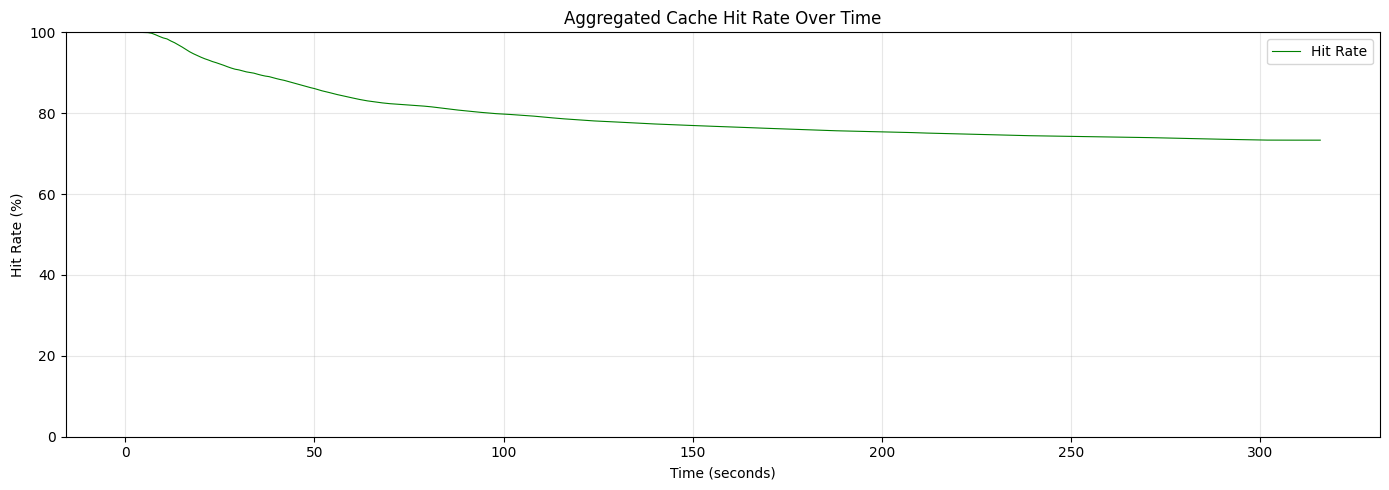

In [21]:
# Aggregated: Hit Rate
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["hit_rate"], 'g-', linewidth=0.8, label="Hit Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("Hit Rate (%)")
plt.title("Aggregated Cache Hit Rate Over Time")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


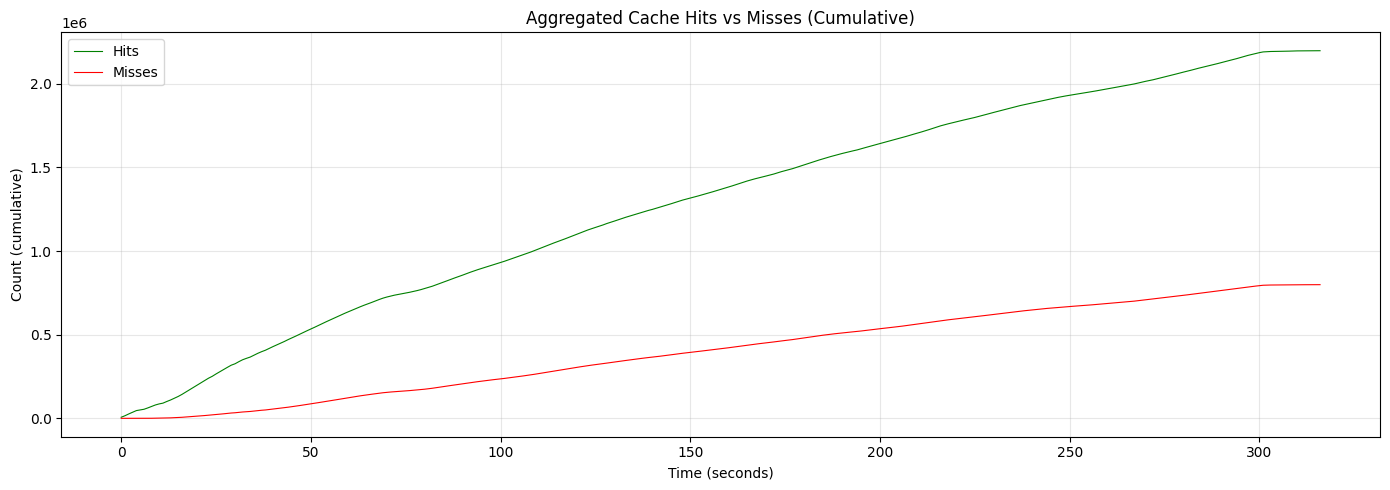

In [22]:
# Aggregated: Hits and Misses (cumulative)
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["hits"], 'g-', linewidth=0.8, label="Hits")
plt.plot(df_agg["time_normalized"], df_agg["misses"], 'r-', linewidth=0.8, label="Misses")
plt.xlabel("Time (seconds)")
plt.ylabel("Count (cumulative)")
plt.title("Aggregated Cache Hits vs Misses (Cumulative)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


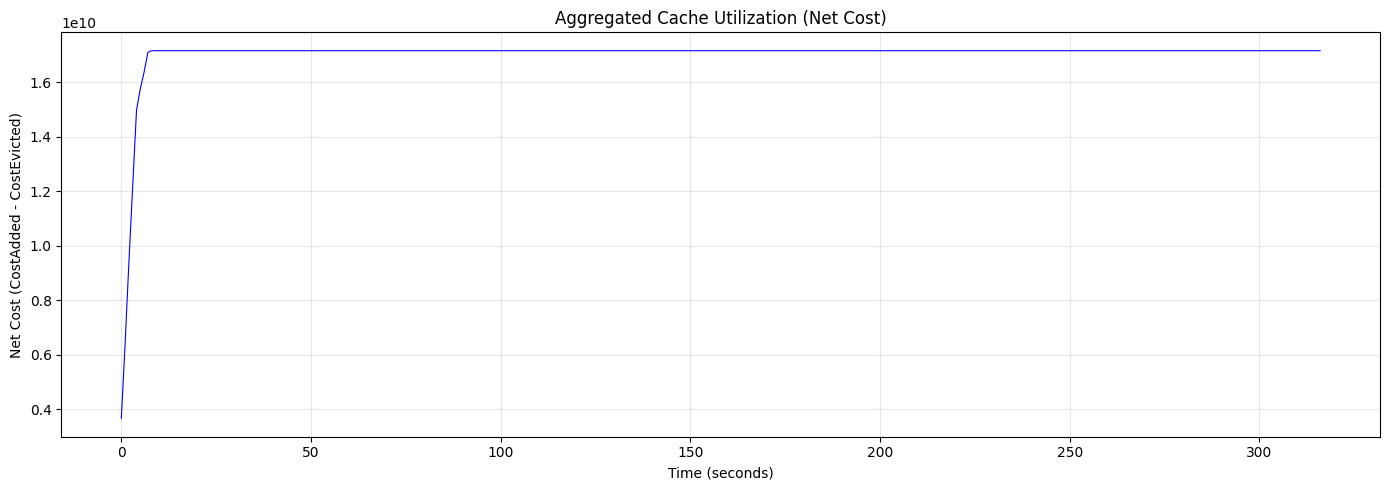

In [23]:
# Aggregated: Cache Utilization (Net Cost)
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["net_cost"], 'b-', linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Net Cost (CostAdded - CostEvicted)")
plt.title("Aggregated Cache Utilization (Net Cost)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


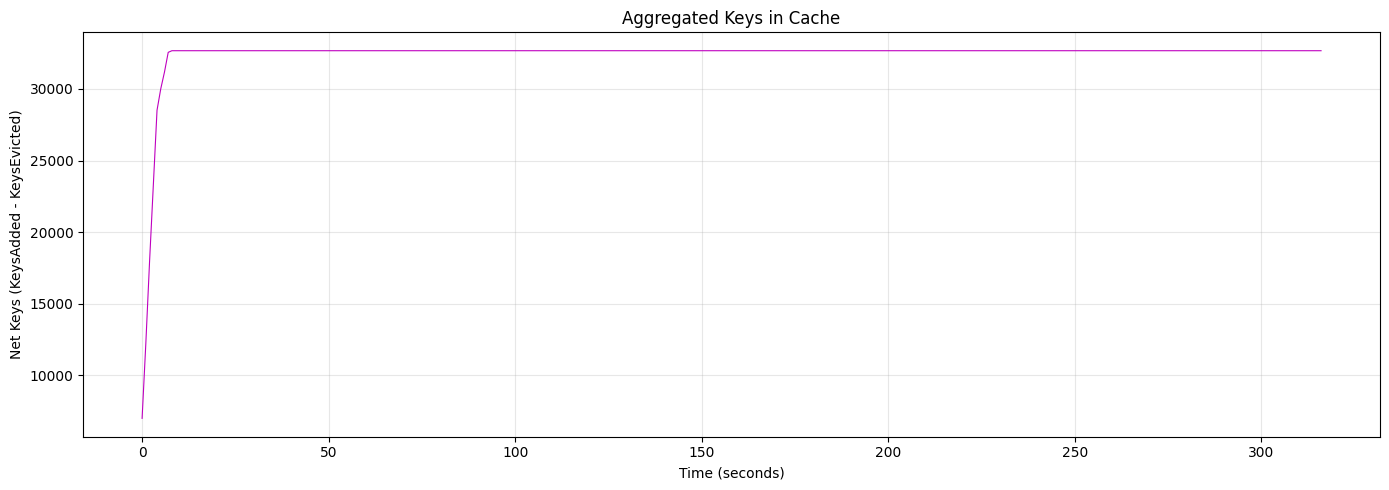

In [24]:
# Aggregated: Keys in Cache (Net Keys)
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["net_keys"], 'm-', linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Net Keys (KeysAdded - KeysEvicted)")
plt.title("Aggregated Keys in Cache")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


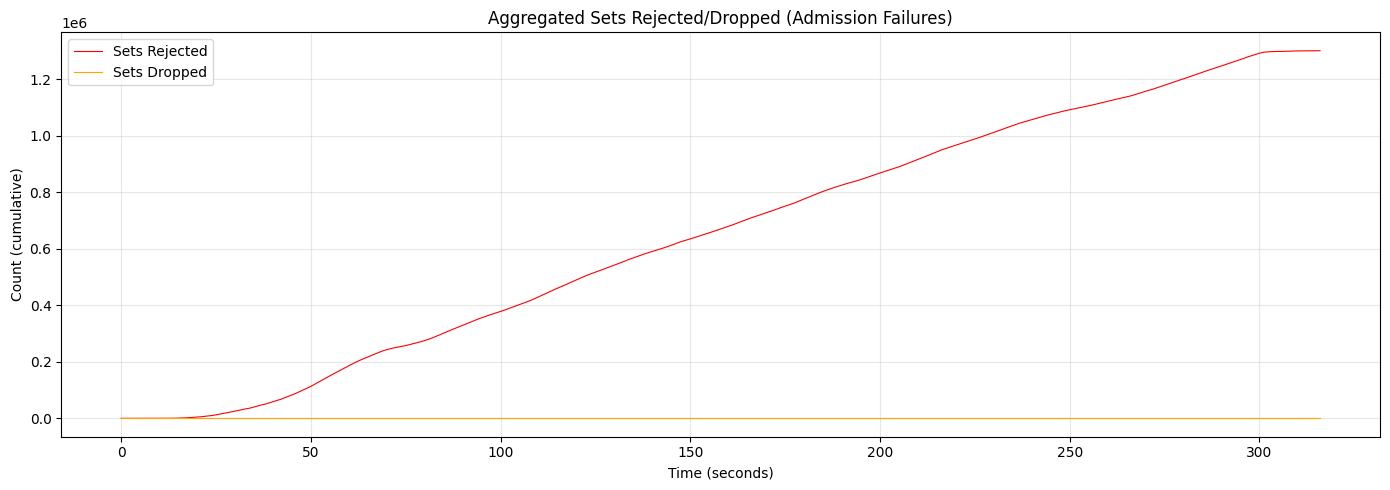

In [25]:
# Aggregated: Sets Rejected (Admission Failures)
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["sets_rejected"], 'r-', linewidth=0.8, label="Sets Rejected")
plt.plot(df_agg["time_normalized"], df_agg["sets_dropped"], 'orange', linewidth=0.8, label="Sets Dropped")
plt.xlabel("Time (seconds)")
plt.ylabel("Count (cumulative)")
plt.title("Aggregated Sets Rejected/Dropped (Admission Failures)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


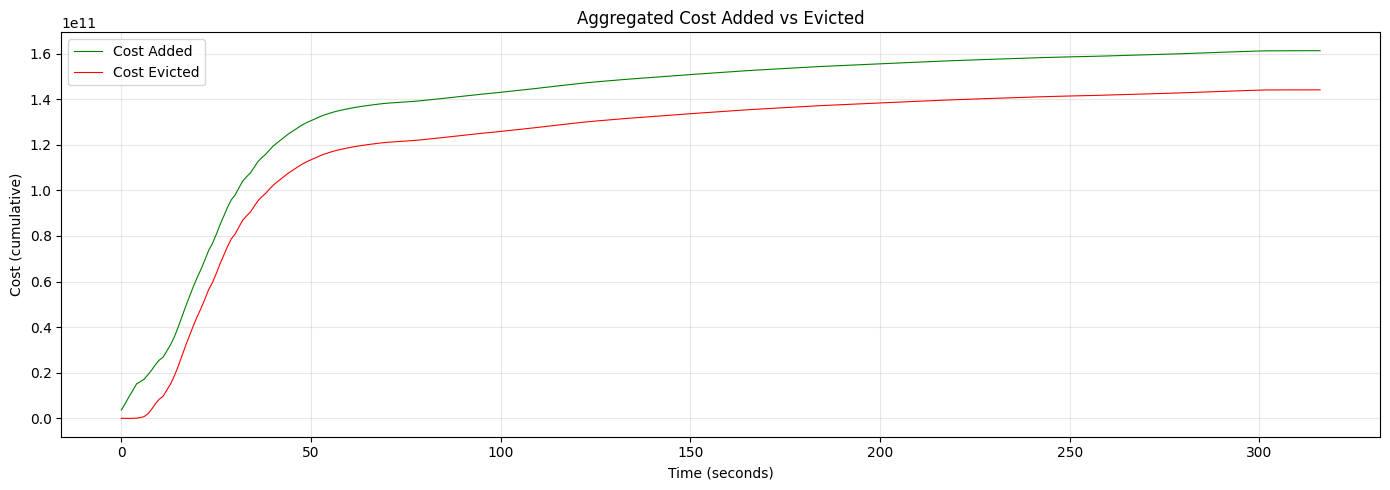

In [26]:
# Aggregated: Cost Added vs Evicted
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["cost_added"], 'g-', linewidth=0.8, label="Cost Added")
plt.plot(df_agg["time_normalized"], df_agg["cost_evicted"], 'r-', linewidth=0.8, label="Cost Evicted")
plt.xlabel("Time (seconds)")
plt.ylabel("Cost (cumulative)")
plt.title("Aggregated Cost Added vs Evicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Per-Shard Metrics


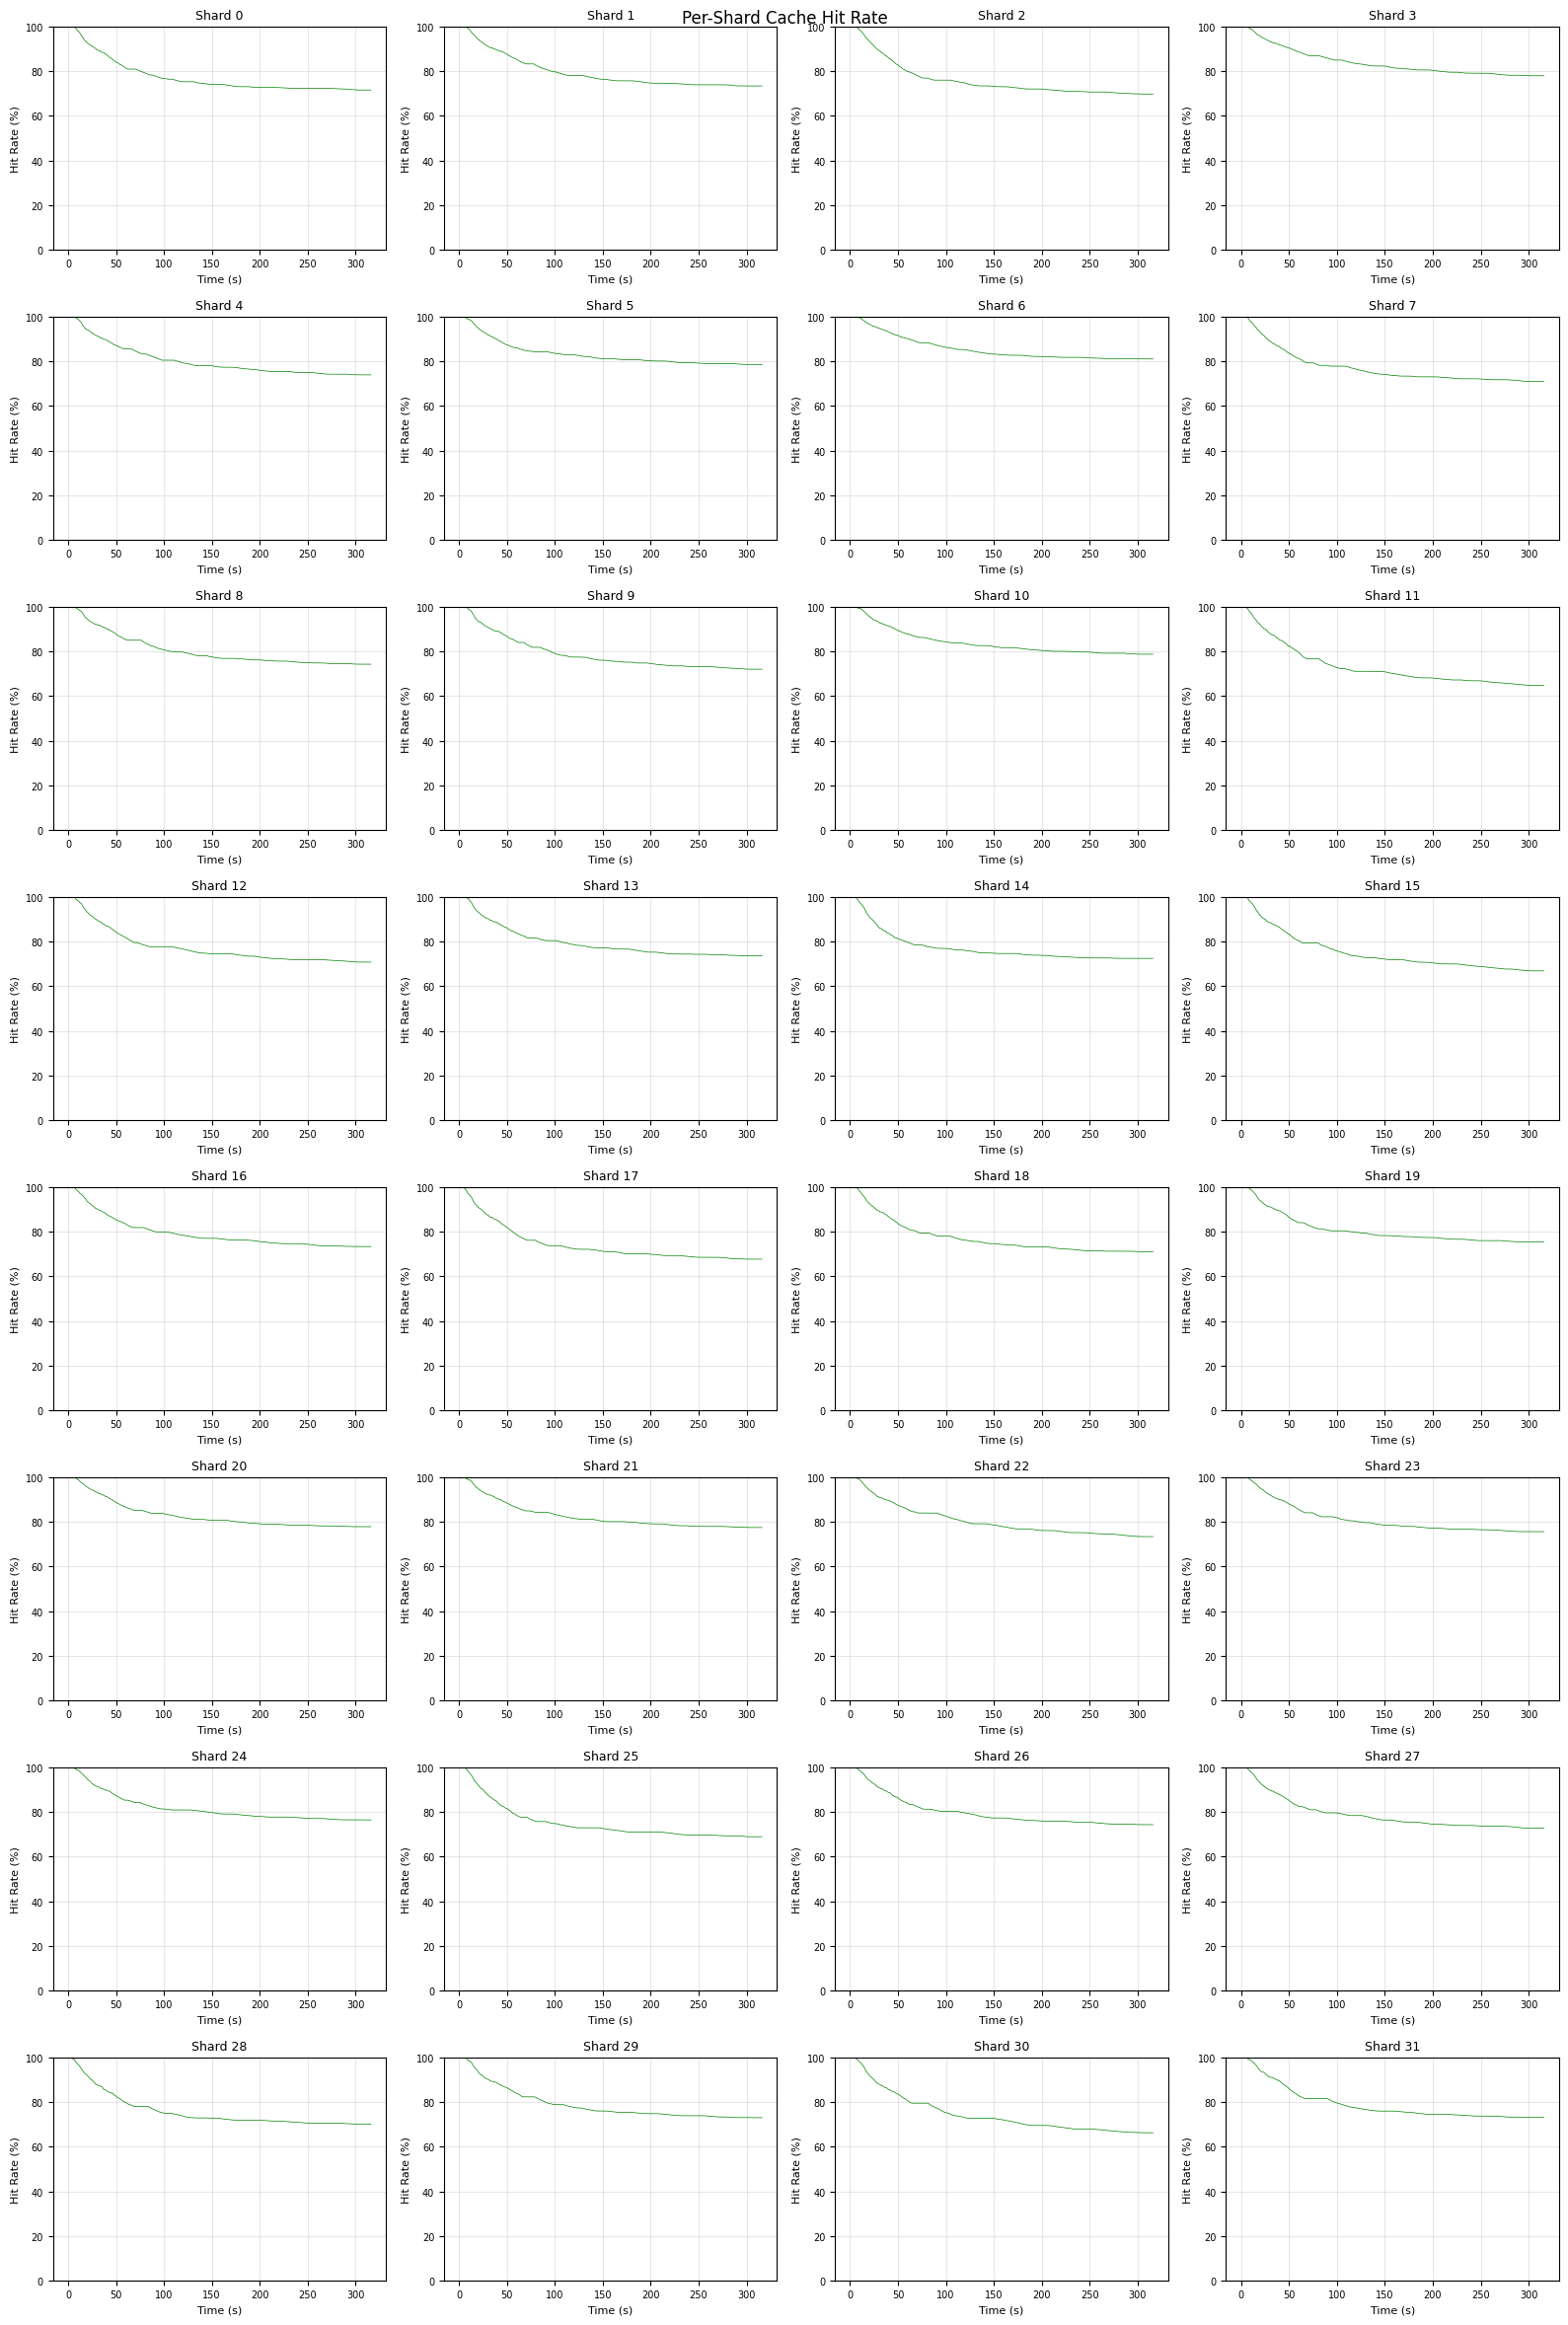

In [27]:
# Per-Shard: Hit Rate (individual plots)
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["hit_rate"], 'g-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("Hit Rate (%)", fontsize=8)
        axes[idx].set_ylim(0, 100)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard Cache Hit Rate", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")


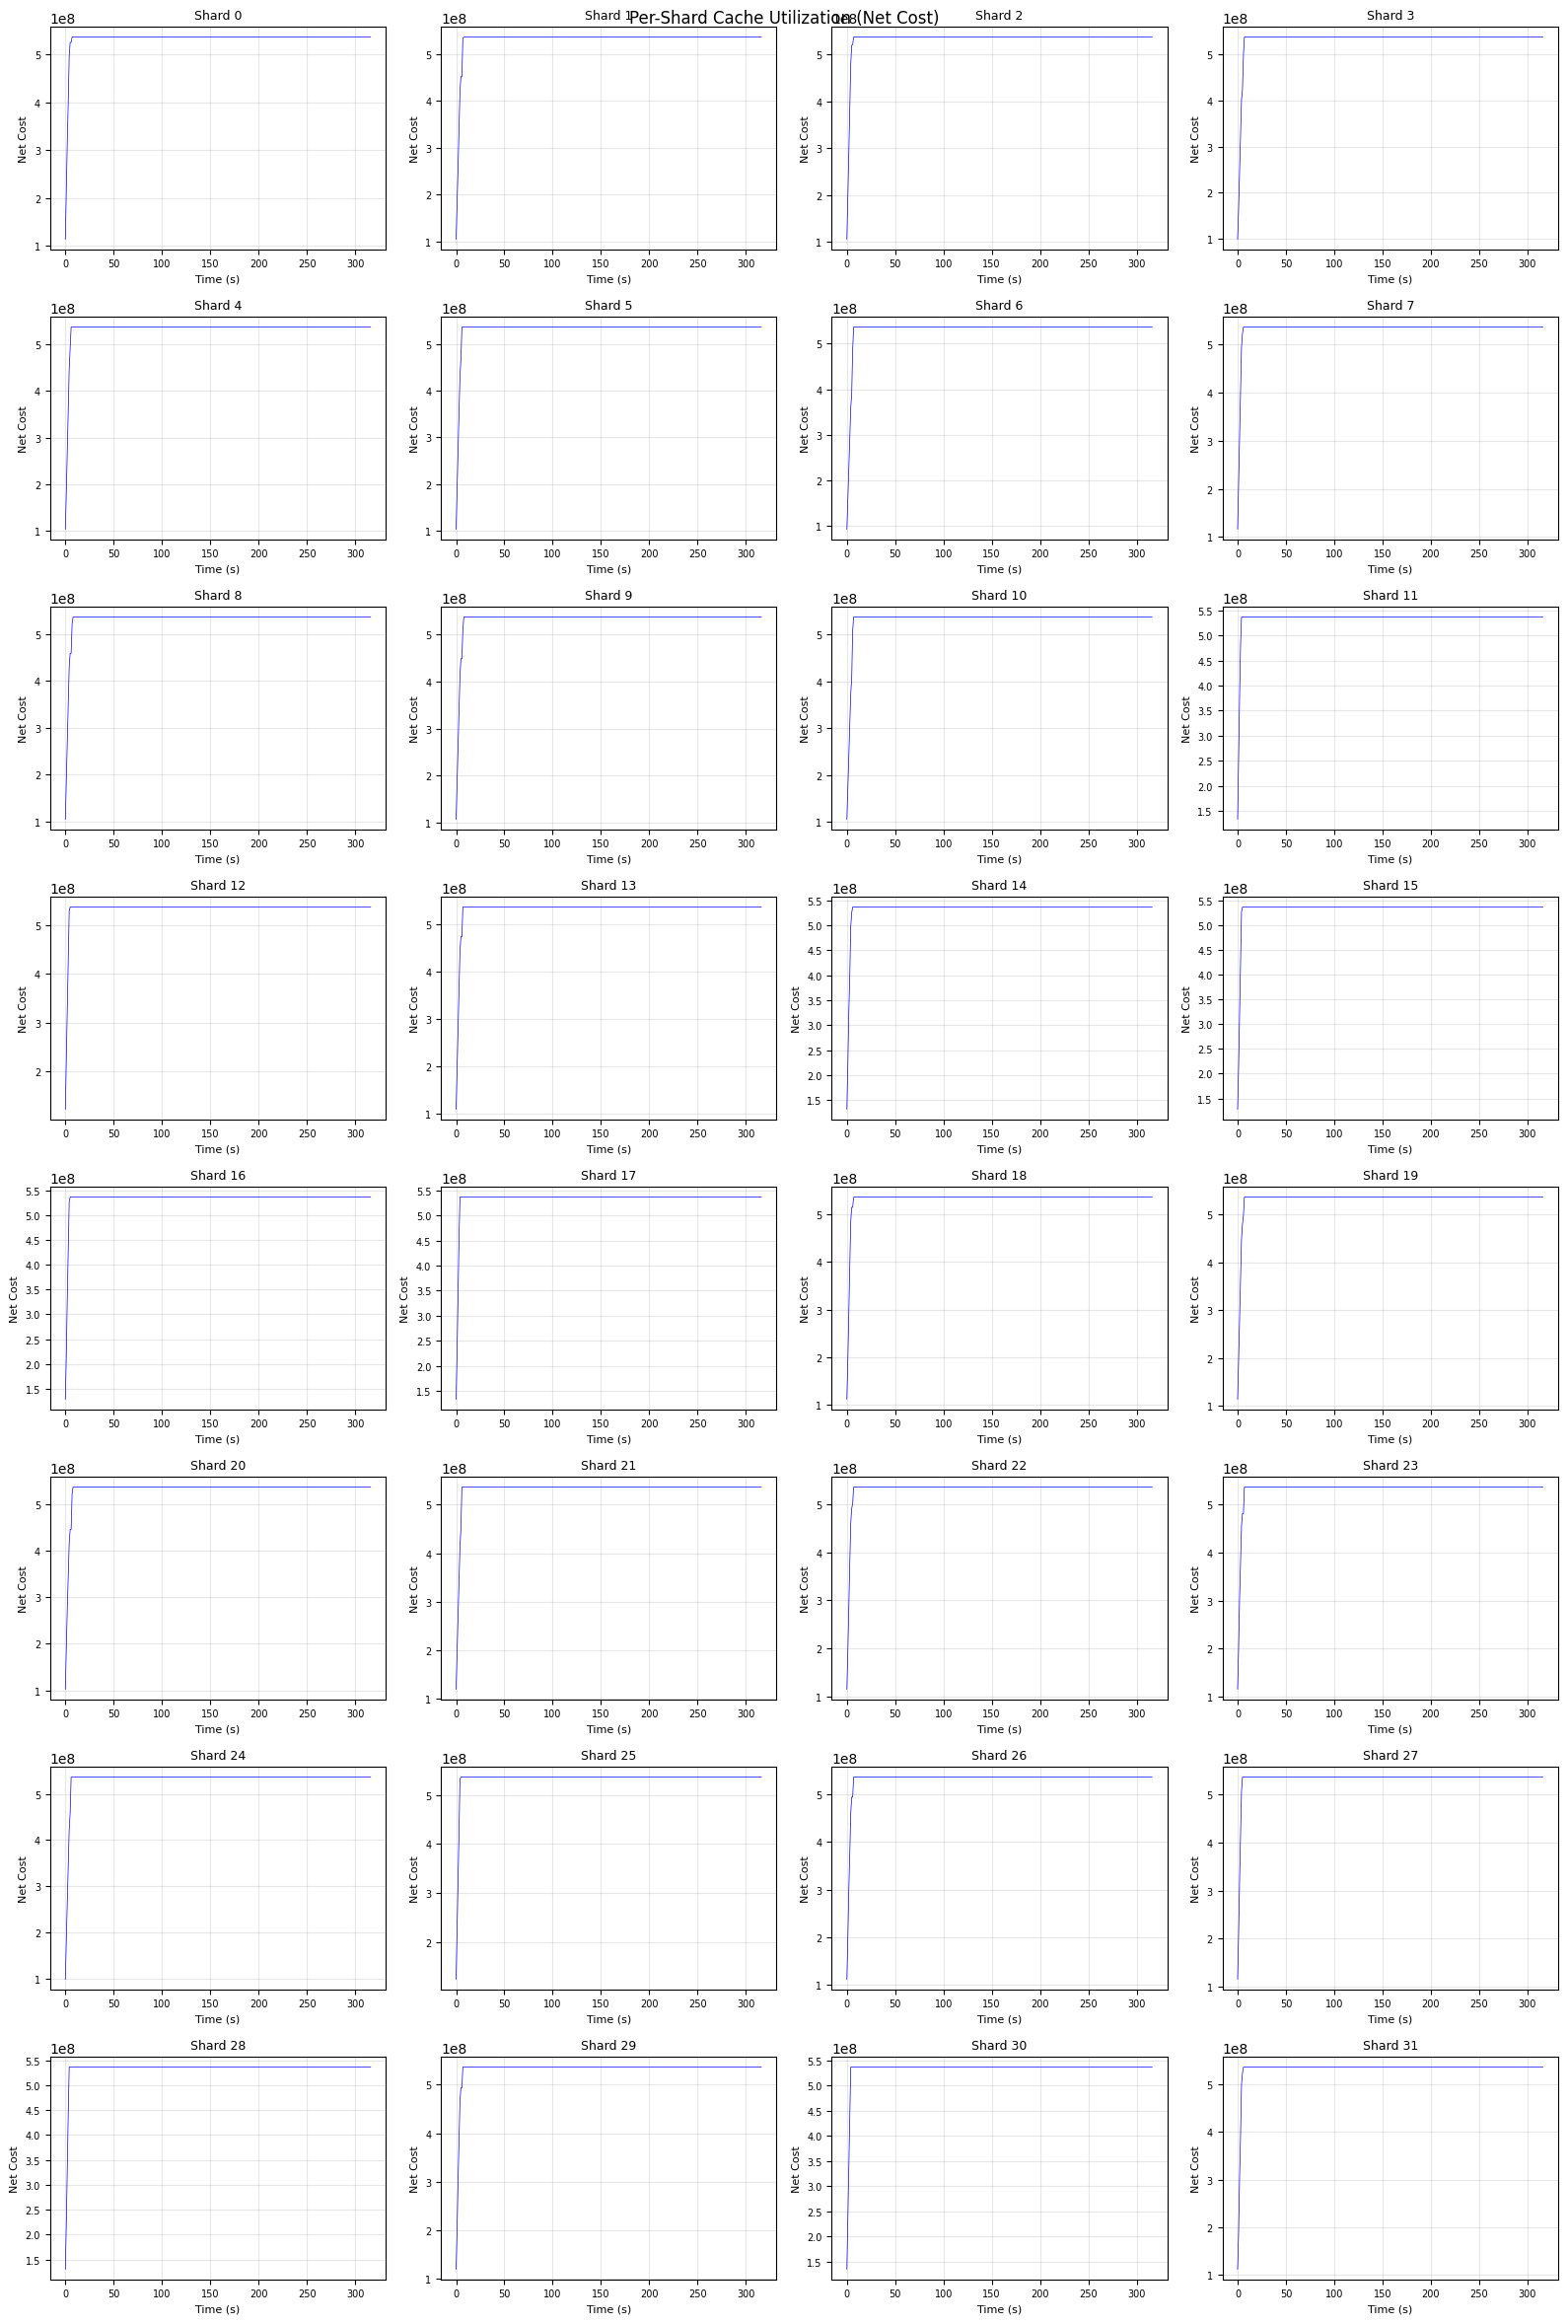

In [28]:
# Per-Shard: Net Cost (Cache Utilization)
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["net_cost"], 'b-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("Net Cost", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard Cache Utilization (Net Cost)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")


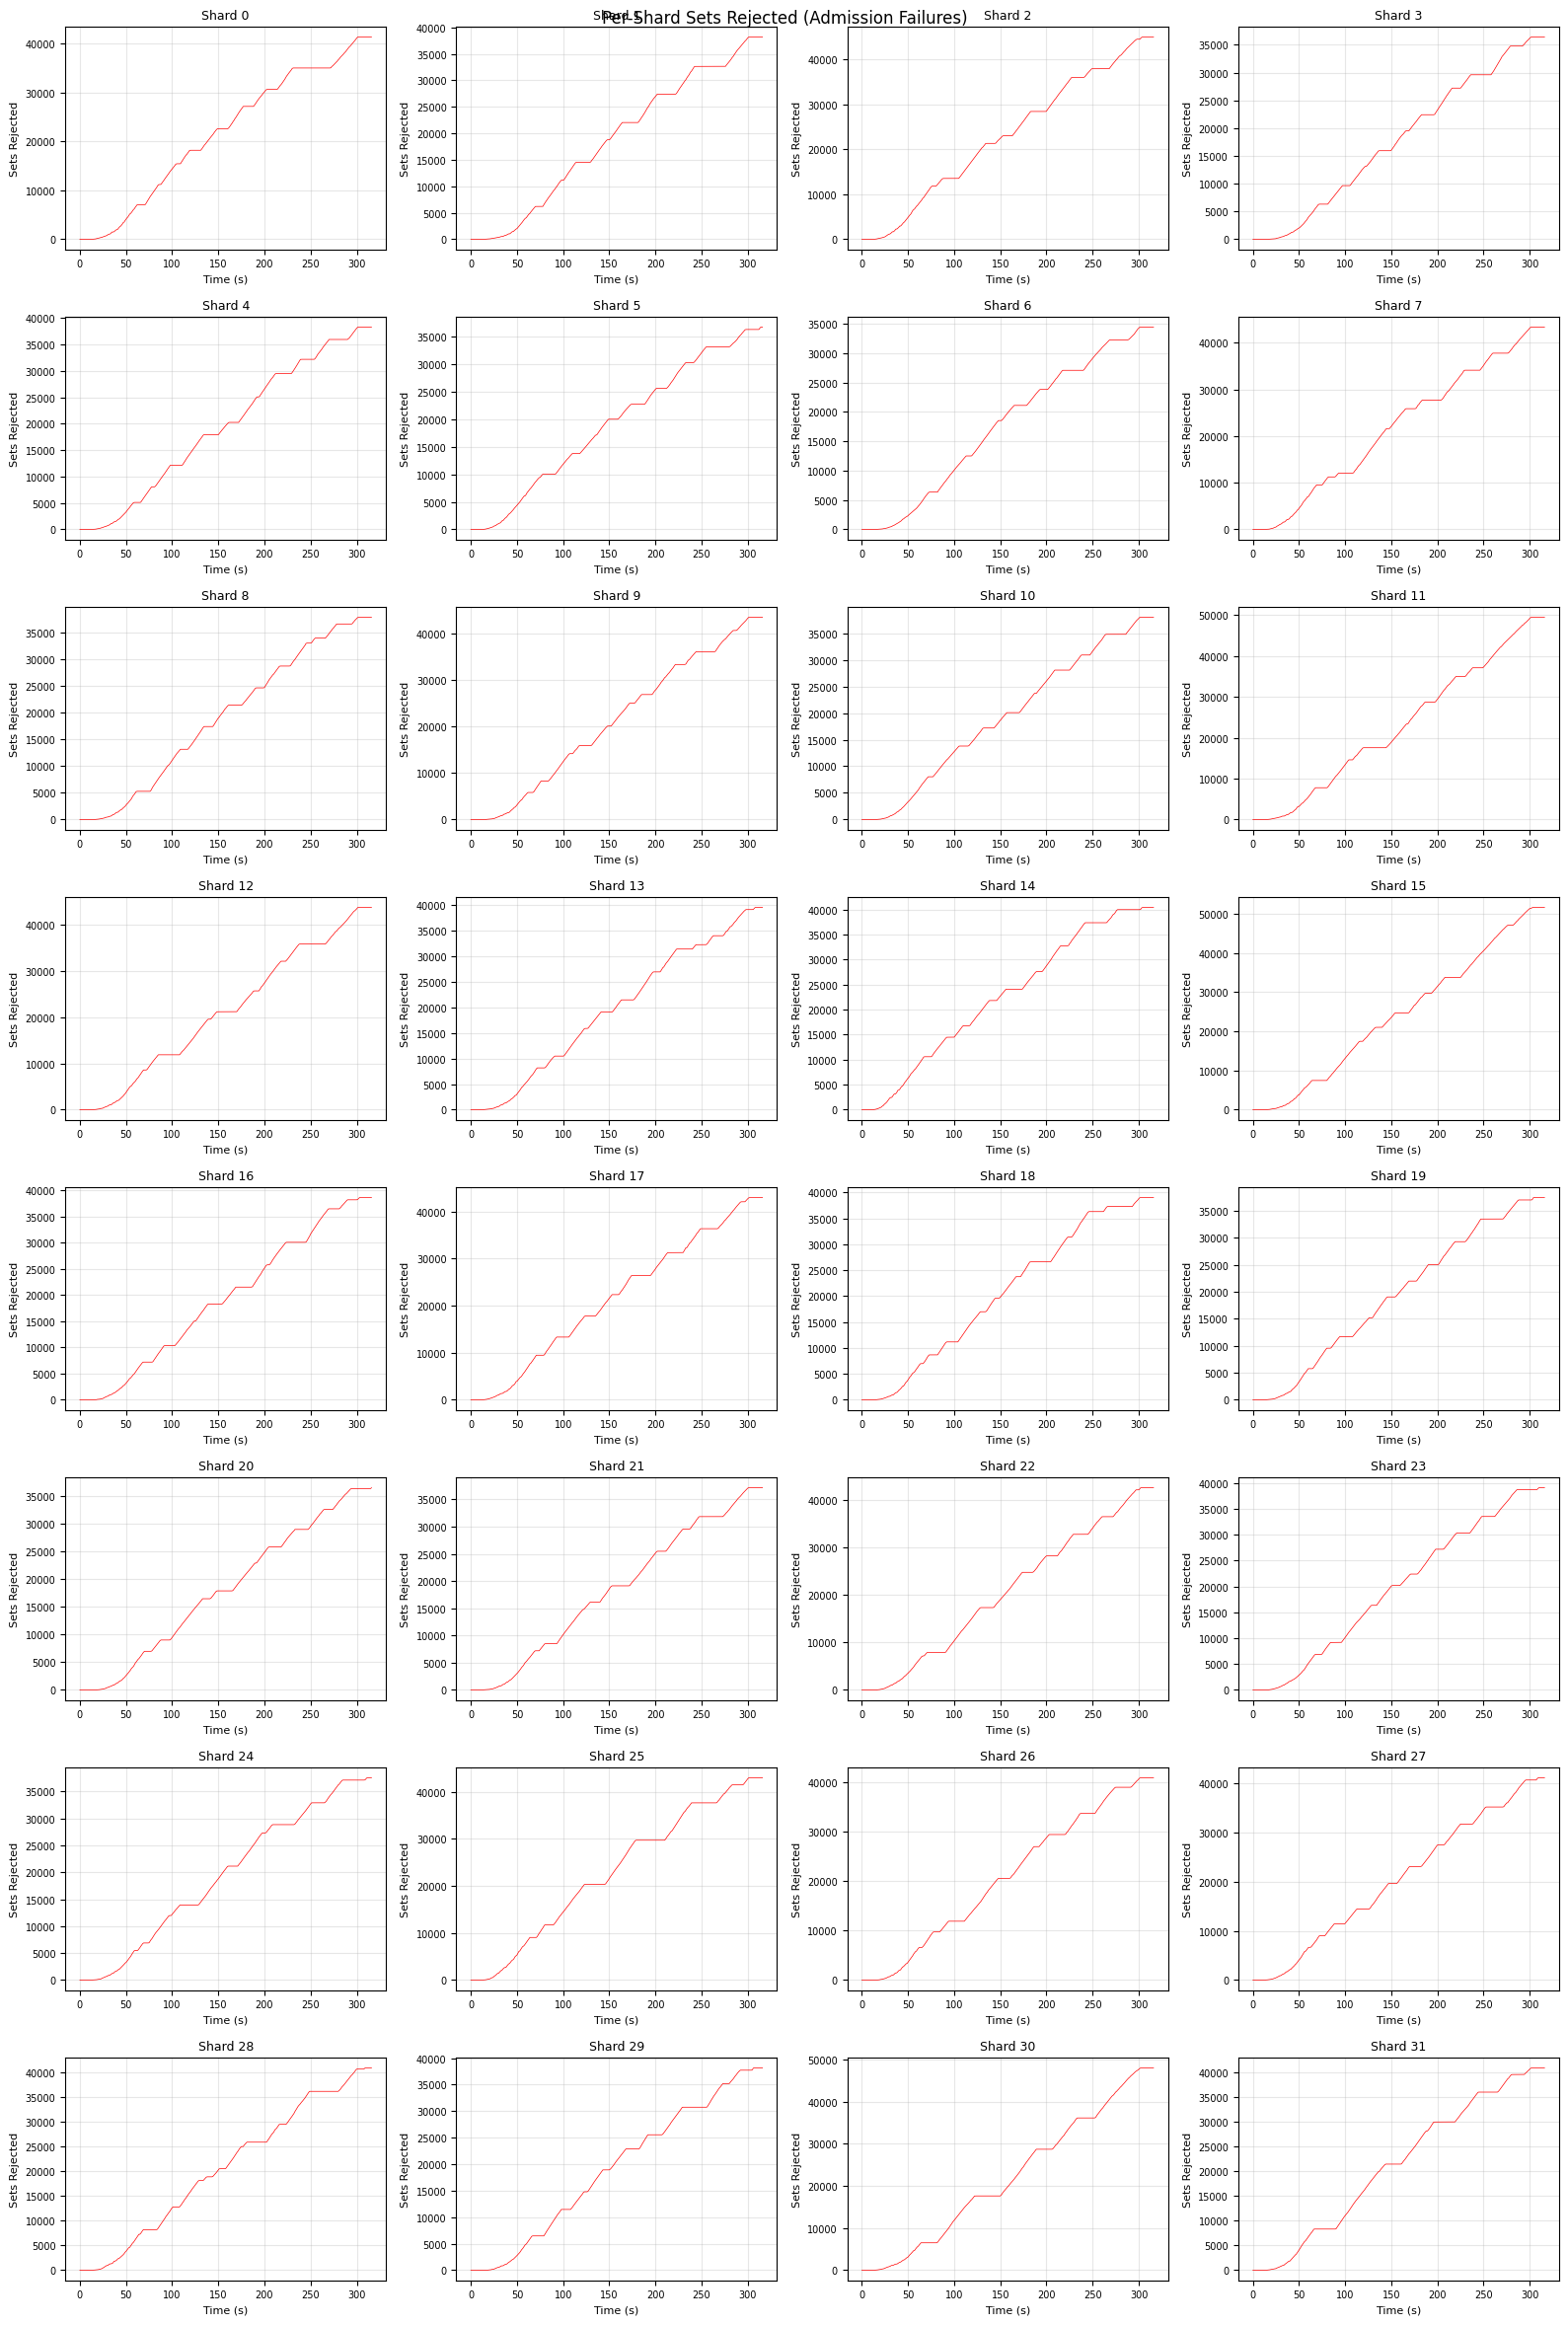

In [29]:
# Per-Shard: Sets Rejected
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["sets_rejected"], 'r-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("Sets Rejected", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard Sets Rejected (Admission Failures)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")


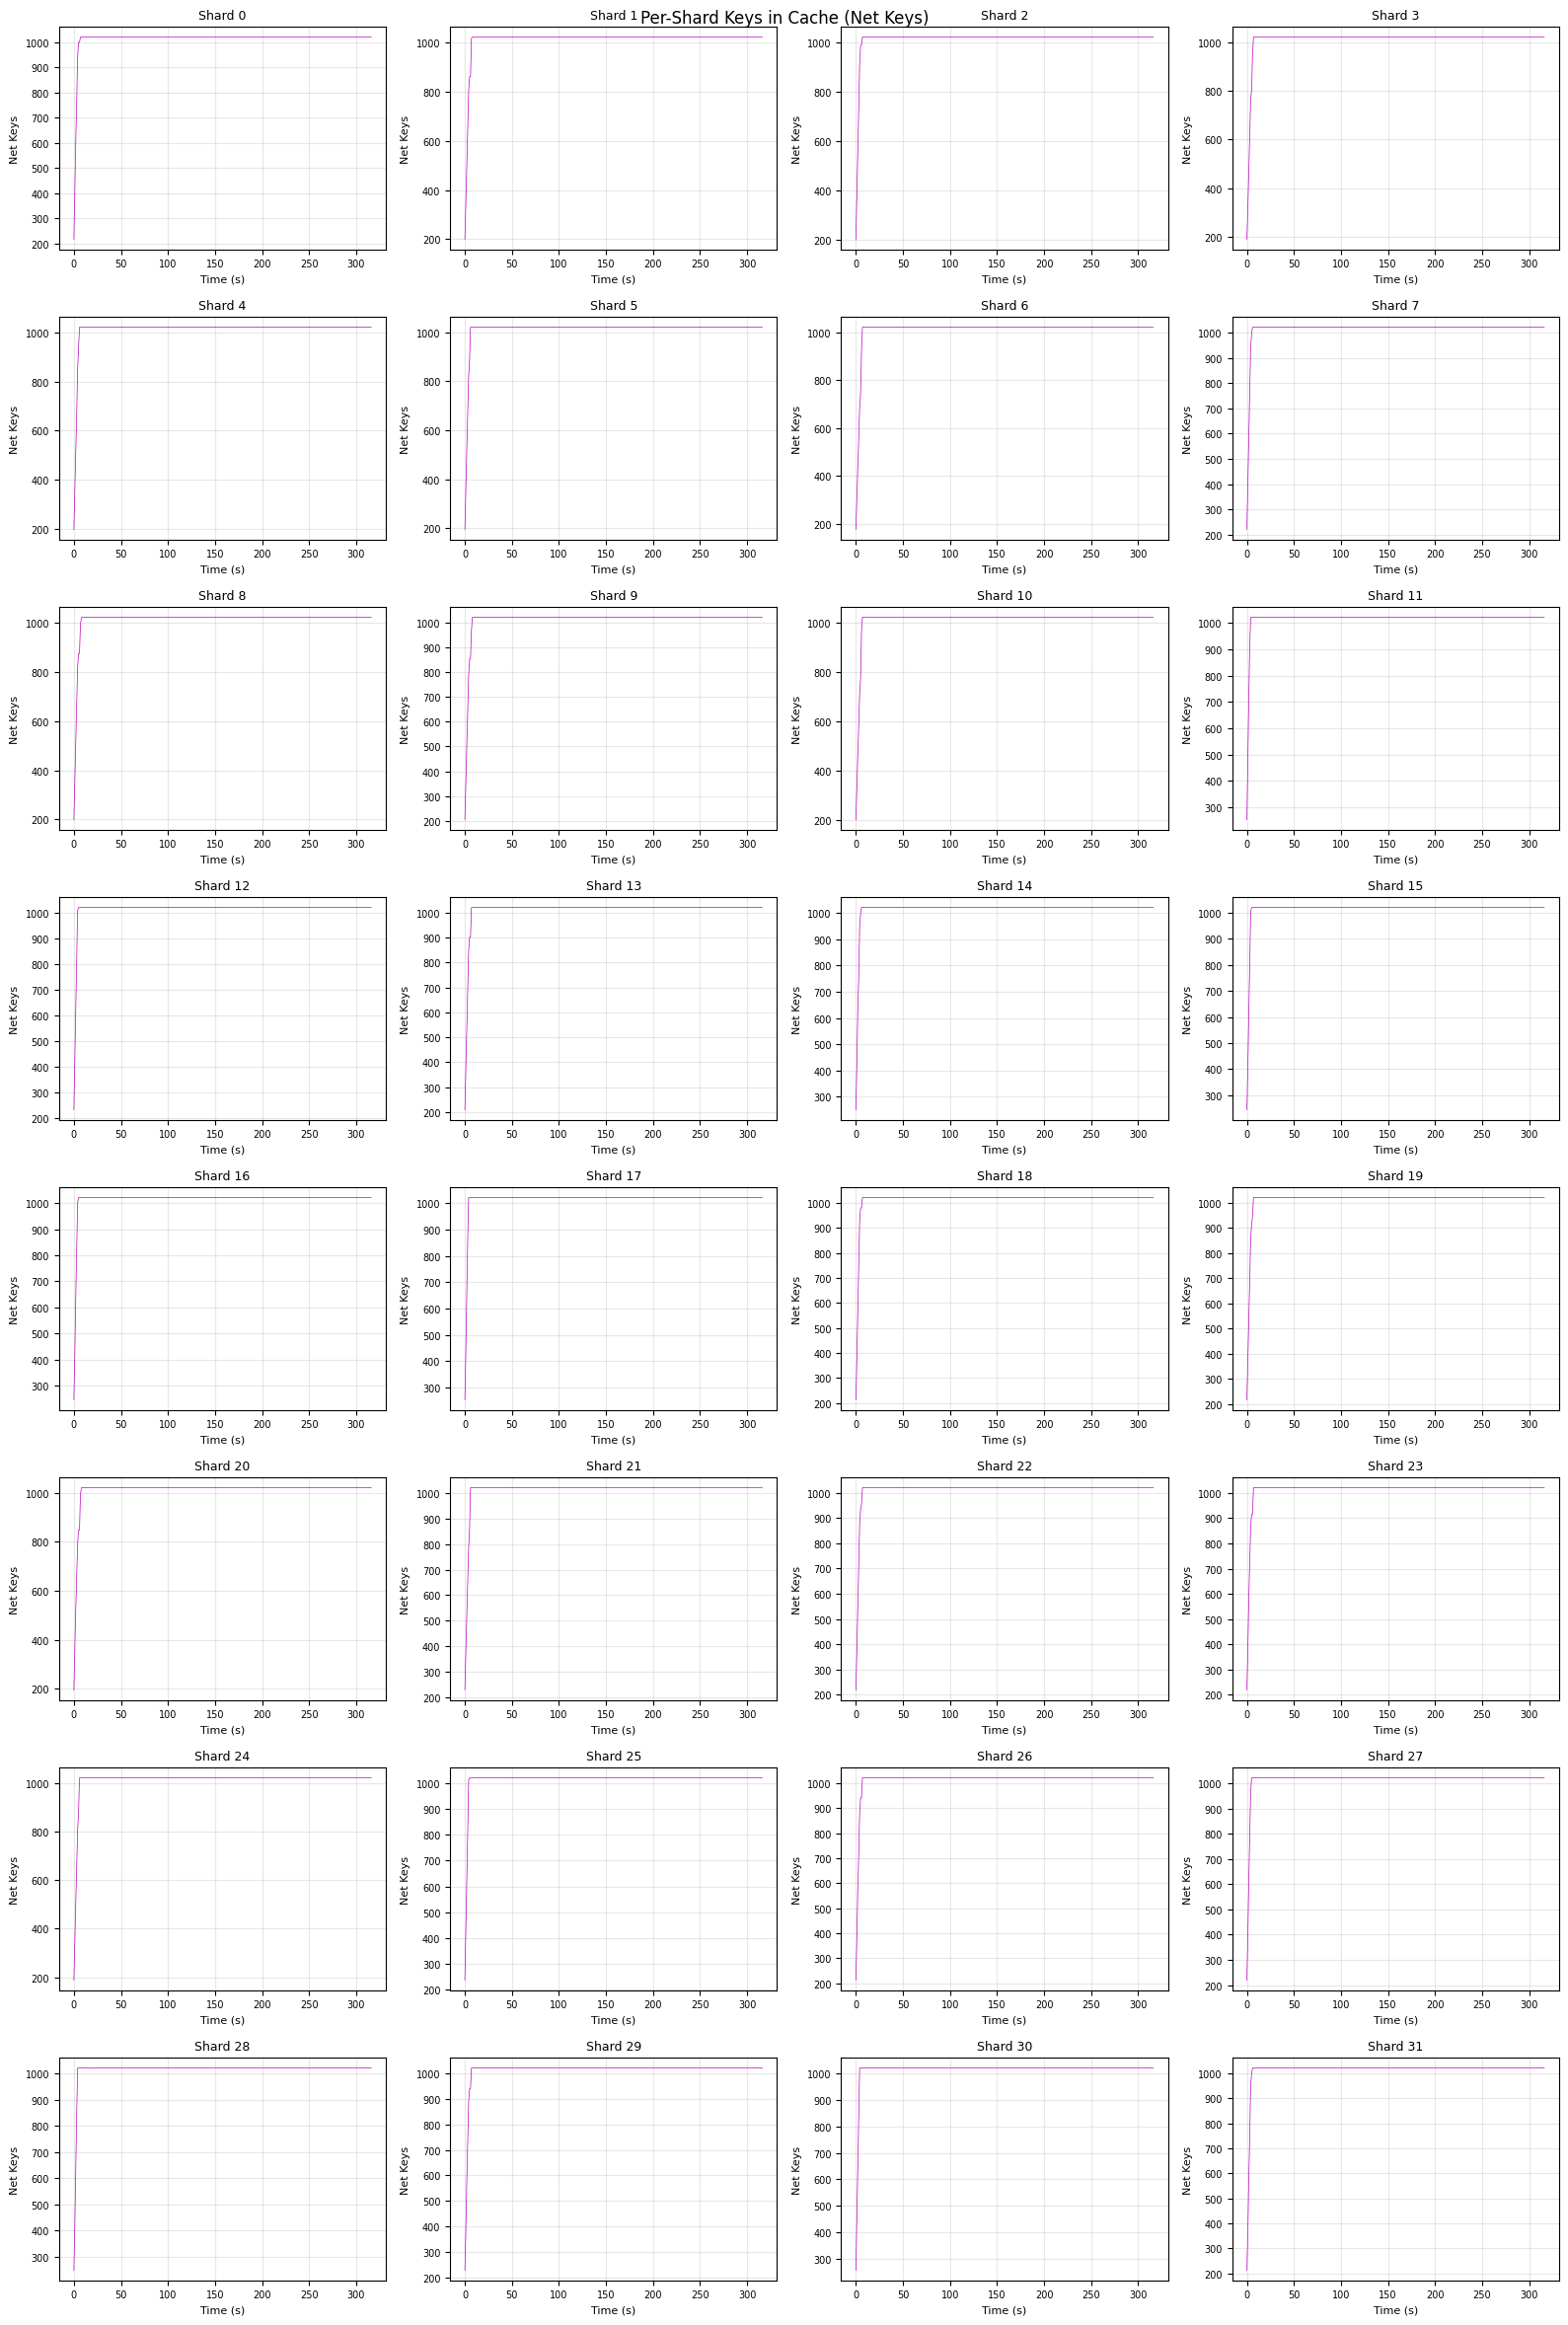

In [30]:
# Per-Shard: Net Keys
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["net_keys"], 'm-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("Net Keys", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard Keys in Cache (Net Keys)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")


## Summary Statistics


In [31]:
# Aggregated summary statistics
print("=" * 80)
print("Aggregated Cache Metrics Summary (Final Values)")
print("=" * 80)

final = df_agg.iloc[-1]
total_requests = final["hits"] + final["misses"]
hit_rate = (final["hits"] / total_requests * 100) if total_requests > 0 else 0

print(f"{'Total Hits:':<30} {final['hits']:>15,.0f}")
print(f"{'Total Misses:':<30} {final['misses']:>15,.0f}")
print(f"{'Total Requests:':<30} {total_requests:>15,.0f}")
print(f"{'Overall Hit Rate:':<30} {hit_rate:>14.2f}%")
print("-" * 80)
print(f"{'Cost Added:':<30} {final['cost_added']:>15,.0f}")
print(f"{'Cost Evicted:':<30} {final['cost_evicted']:>15,.0f}")
print(f"{'Net Cost (Utilization):':<30} {final['net_cost']:>15,.0f}")
print("-" * 80)
print(f"{'Keys Added:':<30} {final['keys_added']:>15,.0f}")
print(f"{'Keys Evicted:':<30} {final['keys_evicted']:>15,.0f}")
print(f"{'Keys Updated:':<30} {final['keys_updated']:>15,.0f}")
print(f"{'Net Keys (in Cache):':<30} {final['net_keys']:>15,.0f}")
print("-" * 80)
print(f"{'Sets Rejected:':<30} {final['sets_rejected']:>15,.0f}")
print(f"{'Sets Dropped:':<30} {final['sets_dropped']:>15,.0f}")
print(f"{'Gets Dropped:':<30} {final['gets_dropped']:>15,.0f}")
print(f"{'Gets Kept:':<30} {final['gets_kept']:>15,.0f}")
print("=" * 80)


Aggregated Cache Metrics Summary (Final Values)
Total Hits:                          2,196,956
Total Misses:                          798,815
Total Requests:                      2,995,771
Overall Hit Rate:                       73.34%
--------------------------------------------------------------------------------
Cost Added:                    161,252,776,344
Cost Evicted:                  144,087,953,048
Net Cost (Utilization):         17,164,823,296
--------------------------------------------------------------------------------
Keys Added:                            306,933
Keys Evicted:                          274,261
Keys Updated:                        2,196,955
Net Keys (in Cache):                    32,672
--------------------------------------------------------------------------------
Sets Rejected:                       1,301,370
Sets Dropped:                                0
Gets Dropped:                                0
Gets Kept:                             759,232


In [32]:
# Per-shard final values summary
if num_shards > 0:
    print("\n" + "=" * 110)
    print("Per-Shard Final Values")
    print("=" * 110)
    print(f"{'Shard':>5} {'Hits':>12} {'Misses':>12} {'Hit Rate':>10} {'Net Cost':>12} {'Net Keys':>12} {'Rejected':>12}")
    print("-" * 110)
    
    for shard_id in shard_ids:
        shard_df = df[df["shard_id"] == shard_id]
        last_row = shard_df.iloc[-1]
        total = last_row["hits"] + last_row["misses"]
        hr = (last_row["hits"] / total * 100) if total > 0 else 0
        print(f"{shard_id:>5} {last_row['hits']:>12,.0f} {last_row['misses']:>12,.0f} {hr:>9.2f}% "
              f"{last_row['net_cost']:>12,.0f} {last_row['net_keys']:>12,.0f} {last_row['sets_rejected']:>12,.0f}")
    print("=" * 110)
else:
    print("No per-shard data available")



Per-Shard Final Values
Shard         Hits       Misses   Hit Rate     Net Cost     Net Keys     Rejected
--------------------------------------------------------------------------------------------------------------
    0       63,988       25,304     71.66%  536,400,728        1,021       41,371
    1       66,647       24,050     73.48%  536,400,728        1,021       38,154
    2       63,718       27,511     69.84%  536,400,728        1,021       45,018
    3       78,695       22,095     78.08%  536,400,728        1,021       36,407
    4       67,454       23,656     74.04%  536,400,728        1,021       38,261
    5       79,020       21,486     78.62%  536,400,728        1,021       36,686
    6       89,825       20,811     81.19%  536,400,728        1,021       34,428
    7       64,201       26,167     71.04%  536,400,728        1,021       43,320
    8       67,521       23,253     74.38%  536,400,728        1,021       37,757
    9       69,547       26,856     72.14%  5